# 0.Assignments

👾 這個陽春的聊天機器人需要被優化！<br>
若是一個對話串不間斷地持續進行，送進去的訊息量會很多，tokens數量也會跟著增加，會需要花比較多費用(💸💸💸)，也可能使模型的回應雜訊比較多而回應受到干擾，所以我們可以優化短期記憶。<br>
另外，我們希望優化使用者體驗，我們可以根據聊天的內容整理出使用者的屬性，並在每一次跟使用者聊天時，都能根據這個使用者的狀況給予客製化的回應，因此我們要加入長期記憶的功能！

<br>

### 1. 短期記憶優化

(1) 🔰 [基本版] 在短期記憶中，將chatbot node送入llm的訊息中加入trim的優化機制 (依據適當的tokens數量決定)


<br>

### 2. 加入長期記憶

加入長期記憶，讓聊天機器人能夠記住使用者的資訊（名字、偏好語言、興趣），在下一次對話也能針對同個使用者的資訊，給予個人化的回答。

(1) 🔰 [基本版]
- chatbot node: 在chatbot node中，將該使用者的資訊取出，讓入prompt中讓llm依據使用者的資訊給予個人化的回答

- write_memory node: 在每一次生成回答後，將使用者的資訊整理成一段對使用者的描述(使用llm，給予system prompt做指引，自行設計如何整理、需要整理哪些資訊)，將整理完的資訊整理到store (可跨threads存取的地方)。

- config: config從原本的短期記憶只有thread_id, 也要加入user_id

<img src="https://drive.google.com/uc?export=view&id=1H4Y0WplOi6R4Eo06Ac2JA_9TbZa2YaRD" width="100"/>


(2) 👨‍🎓 [進階版]
- chatbot node: 可以決定使用者的問題是否需要從長期記憶中取得資訊，以及需要取得什麼資訊
- write_memory node: 可以整理成特定格式 (例如：使用with_structured_output，相關概念可以延伸到R3 tool calling內容)。例如：
```
user_profile = {
  "first_name": "XXXX",
  "last_name": "OOO",
  "preferred_lang": ["en", "zh-tw"]
}
```
- 也可以自行將graph結構調整自己喜歡的(增刪不同node, conditional router, ...)
<br>
備註：基本版是需要大家完成的，進階版可以自行決定是否挑戰，Enjoy the ride! 😎

# 1.短期記憶

## (1) 基本版
🔰 [基本版] 在短期記憶中，將chatbot node送入llm的訊息中加入trim的優化機制 (依據適當的tokens數量決定)

note: 可以邊做邊看一下trim設定的效果以及內部運作的機制

In [1]:
%%capture --no-stderr
!pip install -U langgraph langchain_openai==0.3.15 langchain transformers bitsandbytes langchain-huggingface


In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline, BitsAndBytesConfig
from langchain_huggingface import HuggingFacePipeline

# 會需要一點時間
# 使用 4-bit 量化模型
model_id = "MediaTek-Research/Breeze-7B-Instruct-v1_0"

quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    llm_int8_threshold=6.0,
)

# 載入 tokenizer 與 4-bit 模型
tokenizer = AutoTokenizer.from_pretrained(model_id, use_fast=True)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    device_map="auto",
    quantization_config=quant_config,
    trust_remote_code=True
)

tokenizer_config.json:   0%|          | 0.00/2.33k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/911k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.79M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

...

model-00004-of-00004.safetensors:   0%|          | 0.00/508M [00:00<?, ?B/s]

model-00001-of-00004.safetensors:   0%|          | 0.00/4.95G [00:00<?, ?B/s]

model-00002-of-00004.safetensors:   0%|          | 0.00/4.92G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

In [3]:
generator = pipeline(
    task="text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=512,
    do_sample=True,
    temperature=0.4,
    return_full_text=False # 僅返回生成的回應內容
)

# 包裝成 LangChain 的 llm 物件
llm = HuggingFacePipeline(pipeline=generator)

Device set to use cuda:0


In [4]:
import os
from google.colab import userdata
os.environ["HF_TOKEN"] = userdata.get('HF_TOKEN')

In [5]:
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace

# 呼叫huggingface上的API模型 (free)
llm_endpoint = HuggingFaceEndpoint(
    repo_id="Qwen/Qwen2.5-32B-Instruct",
    task="text-generation",
    max_new_tokens=512,
    do_sample=False,
    repetition_penalty=1.03,
)
llm_huggingface = ChatHuggingFace(llm=llm_endpoint, verbose=False)

In [35]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import convert_to_openai_messages, SystemMessage, HumanMessage, AIMessage, BaseMessage, trim_messages
from langchain_core.runnables.config import RunnableConfig
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages.utils import count_tokens_approximately

class State(TypedDict):
  messages: Annotated[list, add_messages]

def chatbot(state: State):
  # 💻code below:
  # hint: you can use langchain_core trim_messages function to trim your trim_messages, and count_tokens_approximately to count tokens
  system_prompt = "你是個只能使用繁體中文回答的助理"
  # mode = config["configurable"]["mode"] # 決定要使用哪個模型

  # if mode == "local":
  #   messages = convert_to_openai_messages(state["messages"]) # Convert LangChain messages into OpenAI message dicts.
  #   system_message =  [{"role": "system", "content": system_prompt}]
  #   # apply tokenizer prompt template
  #   prompt = tokenizer.apply_chat_template(
  #       system_message+messages,
  #       tokenize=False,
  #       add_generation_prompt=True
  #   )
  #   response = llm_local.invoke(prompt)
  #   return {"messages": [AIMessage(content=response)]}
  # else:
  system_message = [SystemMessage(content=system_prompt)]
  messages = state["messages"]
  trimmed_messages = trim_messages(messages, max_tokens=70, token_counter=count_tokens_approximately)
  total_tokens = count_tokens_approximately(trimmed_messages)
  print(f"total token in messages:{total_tokens}")
  print(trimmed_messages)
  # if mode == "openai_api":
  #   response = llm_api.invoke(system_message+messages)
  # elif mode == "huggingface":
  response = llm_huggingface.invoke(system_message+trimmed_messages)
  return {"messages": [response]}



# 建立graph
graph_builder = StateGraph(State)
graph_builder.add_node("chatbot", chatbot) # 在graph裡面加入chatbot的node
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

# 加入短期記憶
memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)


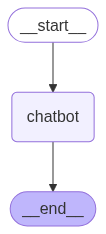

In [36]:
# 看一下graph
from IPython.display import Image, display

try:
  display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
  print(e)
  pass

In [37]:
def stream_graph_updates(user_input: str, config: dict):
    for event in graph.stream({"messages": [{"role": "user", "content": user_input}]}, config):
      if "chatbot" in event:
        for value in event.values():
          print("Assistant:", value["messages"][-1].content)

In [38]:
# 設定對話config (第一次對話)
config = {"configurable": {"thread_id": "conversation_1"}} # thread_id: 對話id

In [39]:
# 開始對話 (可以輸入quit, exit, q，三選一停止對話)
while True:
  try:
    user_input = input("User: ")
    if user_input.lower() in ["quit", "exit", "q"]:
      print("Goodbye!")
      break
    stream_graph_updates(user_input, config)
  except Exception as e:
    print(e)
    break

User: 嗨 我是火影忍者迷
total token in messages:7
[HumanMessage(content='嗨 我是火影忍者迷', additional_kwargs={}, response_metadata={}, id='f336796a-11c5-4034-91b7-60feae163a73')]
Assistant: 嗨！火影忍者是一部非常有名的動畫與漫畫作品，你喜歡哪個角色或是劇情的部分呢？如果有任何關於火影忍者的问题，我很乐意帮你解答。
User: 我喜歡宇智波佐助
total token in messages:34
[HumanMessage(content='嗨 我是火影忍者迷', additional_kwargs={}, response_metadata={}, id='f336796a-11c5-4034-91b7-60feae163a73'), AIMessage(content='嗨！火影忍者是一部非常有名的動畫與漫畫作品，你喜歡哪個角色或是劇情的部分呢？如果有任何關於火影忍者的问题，我很乐意帮你解答。', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 42, 'prompt_tokens': 32, 'total_tokens': 74}, 'model_name': 'Qwen/Qwen2.5-32B-Instruct', 'system_fingerprint': None, 'finish_reason': 'stop', 'logprobs': None}, id='run--37461e4d-ba63-4048-9aa6-fd8194112898-0', usage_metadata={'input_tokens': 32, 'output_tokens': 42, 'total_tokens': 74}), HumanMessage(content='我喜歡宇智波佐助', additional_kwargs={}, response_metadata={}, id='5153510d-3bf2-4f84-bf96-6bb26658c6d6')]
Assistant: 宇智波佐助確實是一位非常

In [28]:
# 開始對話 (可以輸入quit, exit, q，三選一停止對話)
while True:
  try:
    user_input = input("User: ")
    if user_input.lower() in ["quit", "exit", "q"]:
      print("Goodbye!")
      break
    stream_graph_updates(user_input, config)
  except Exception as e:
    print(e)
    break

User: 嗨 我是火影忍者迷
total token in messages:7
Assistant: 嗨！火影忍者的世界確實非常吸引人，你喜歡哪一位角色或是哪一場戰鬥呢？我們可以聊聊這方面的話題。
User: 我喜歡宇智波佐助
total token in messages:30
Assistant: 宇智波佐助是很多人喜歡的角色，他不僅擁有強大的忍術能力，還有著豐富的情感故事線。在他的成長過程中，為了報仇和尋求力量，佐助經歷了很多困難和抉擇。他的眼神中總是透露出堅決和孤獨，讓許多觀眾感到既心疼又佩服。你特別欣賞他哪一方面的性格或特點呢？
User: 我們來聊點別的
total token in messages:72
Assistant: 好的，我們可以聊聊其他的话题。你對什麼感興趣呢？比如說電影、音樂、旅遊或其他方面？
User: 那你還記得我喜歡甚麼嗎
total token in messages:71
Assistant: 剛才我們聊到你喜歡宇智波佐助，但如果你還有其他的喜好或者特別感興趣的话题，歡迎告訴我，這樣我可以更好地和你交流。你想分享什麼其他的信息呢？
User: 我不喜歡鳴人
total token in messages:58
Assistant: 原來如此，如果你不喜歡鳴人，那我們可以多聊聊其他角色或是完全轉移到另一個話題上。你有其他喜歡的动漫角色或是對哪些主題感興趣呢？例如運動、科技、文學等。
User: 那你還記得我喜歡甚麼 不喜歡什麼嗎
total token in messages:69
Assistant: 之前的對話中，您提過喜歡宇智波佐助而不喜歡漩渦鳴人。如果您有其他喜好或不喜歡的事物想要分享，歡迎告訴我，這樣我能更貼心地提供幫助和資訊給您。您還有其他想要分享的喜好嗎？
User: q
Goodbye!


---

In [29]:
graph.get_state(config)

StateSnapshot(values={'messages': [HumanMessage(content='嗨 我是火影忍者迷', additional_kwargs={}, response_metadata={}, id='e8e9c975-f313-4adc-9ca5-1ac53ff19c05'), AIMessage(content='嗨！火影忍者的世界確實非常吸引人，你喜歡哪一位角色或是哪一場戰鬥呢？我們可以聊聊這方面的話題。', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 34, 'prompt_tokens': 32, 'total_tokens': 66}, 'model_name': 'Qwen/Qwen2.5-32B-Instruct', 'system_fingerprint': None, 'finish_reason': 'stop', 'logprobs': None}, id='run--89641c02-bd29-420d-9257-c972926ba84a-0', usage_metadata={'input_tokens': 32, 'output_tokens': 34, 'total_tokens': 66}), HumanMessage(content='我喜歡宇智波佐助', additional_kwargs={}, response_metadata={}, id='fc082c2a-6997-4a02-962c-0819f33a9d80'), AIMessage(content='宇智波佐助是很多人喜歡的角色，他不僅擁有強大的忍術能力，還有著豐富的情感故事線。在他的成長過程中，為了報仇和尋求力量，佐助經歷了很多困難和抉擇。他的眼神中總是透露出堅決和孤獨，讓許多觀眾感到既心疼又佩服。你特別欣賞他哪一方面的性格或特點呢？', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 84, 'prompt_tokens': 82, 'total_tokens': 166}, 'model_name': 'Qwe

# 2.長期記憶

## (1) 基本版
🔰 [基本版]
- chatbot node: 在chatbot node中，將該使用者的資訊取出，讓入prompt中讓llm依據使用者的資訊給予個人化的回答

- write_memory node: 在每一次生成回答後，將使用者的資訊整理成一段對使用者的描述(使用llm，給予system prompt做指引，自行設計如何整理、需要整理哪些資訊)，將整理完的資訊整理到store (可跨threads存取的地方)。

- config: config從原本的短期記憶只有thread_id, 也要加入user_id

<img src="https://drive.google.com/uc?export=view&id=1H4Y0WplOi6R4Eo06Ac2JA_9TbZa2YaRD" width="100"/>

In [ ]:
%%capture --no-stderr
!pip install langchain_core

In [ ]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.checkpoint.memory import MemorySaver # within-thread memory
from langgraph.store.memory import InMemoryStore # cross-thread store

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

from langchain_core.messages import HumanMessage, SystemMessage, AIMessage


class State(TypedDict):
  messages: Annotated[list, add_messages]

def chatbot(__________):
  # 💻code here:
  # TODO:
  # 依據user_id取得長期記憶
  # 將長期記憶也放進system prompt中，讓llm可以個人化回覆


  return {"messages": [AIMessage(content=response)]}


def write_memory(________):
  # 💻code here:
  # TODO:
  # 將使用者的對話整理成要儲存成長期記憶的資訊，並存入長期記憶

# Define the graph
builder = StateGraph(State)
builder.add_node("chatbot", chatbot)
builder.add_node("write_memory", write_memory)
builder.add_edge(START, "chatbot")
builder.add_edge("chatbot", "write_memory")
builder.add_edge("write_memory", END)


# Compile the graph with the checkpointer fir and store

# 💻Code Here
# 記得放入短期記憶，長期記憶的store
graph = builder.compile(checkpointer=______, store=________)


In [ ]:
# View
from IPython.display import Image, display
try:
  display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
  print(e)
  pass

In [ ]:
def stream_graph_updates(user_input: str, config: dict):
    for event in graph.stream({"messages": [{"role": "user", "content": user_input}]}, config):
        if "chatbot" in event:
          for value in event.values():
              print("Assistant:", value["messages"][-1].content)

In [ ]:
# 使用者A的第一次對話
config = {"configurable": {"thread_id": "conversation_1", "user_id": "user_a"}}

In [ ]:
# 開始對話 (可以輸入quit, exit, q，三選一停止對話)
while True:
  try:
    user_input = input("User: ")
    if user_input.lower() in ["quit", "exit", "q"]:
      print("Goodbye!")
      break
    stream_graph_updates(user_input, config)
  except Exception as e:
    print(e)
    break

In [ ]:
# 使用者A的第二次對話
config = {"configurable": {"thread_id": "conversation_2", "user_id": "user_a"}}

In [ ]:
# 開始對話 (可以輸入quit, exit, q，三選一停止對話)
while True:
  try:
    user_input = input("User: ")
    if user_input.lower() in ["quit", "exit", "q"]:
      print("Goodbye!")
      break
    stream_graph_updates(user_input, config)
  except Exception as e:
    print(e)
    break

## (2) 進階版

👨‍🎓 [進階版]
- chatbot node: 可以決定使用者的問題是否需要從長期記憶中取得資訊，以及需要取得什麼資訊
- write_memory node: 可以整理成特定格式 (例如：使用with_structured_output，相關概念可以延伸到R3 tool calling內容)。例如：
```
user_profile = {
  "first_name": "XXXX",
  "last_name": "OOO",
  "preferred_lang": ["en", "zh-tw"]
}
```
- 也可以自行將graph結構調整自己喜歡的(增刪不同node, conditional router, ...)

In [ ]:
# 💻code here, enjoy the ride 😎
